In [1]:
import sys, os
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [2]:
from pathlib import Path
from typing import Final,List,Optional, Dict, Tuple
from src.data_load import boston_dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
import math 
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from scipy import stats
from scipy.stats import anderson, shapiro, normaltest, kstest, chisquare, probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.signal import find_peaks
from sklearn.decomposition import PCA



statistics for dataset

In [3]:
duplicate_rows = boston_dt.duplicated()
duplicate_rows.sum()

0

In [4]:
boston_dt.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
boston_dt[boston_dt['CHAS']!=0].tail(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
282,0.06129,20.0,3.33,1,0.4429,7.645,49.7,5.2119,5,216.0,14.9,377.07,3.01,46.0
283,0.01501,90.0,1.21,1,0.4010,7.923,24.8,5.8850,1,198.0,13.6,395.52,3.16,50.0
356,8.98296,0.0,18.10,1,0.7700,6.212,97.4,2.1222,24,666.0,20.2,377.73,17.60,17.8
357,3.84970,0.0,18.10,1,0.7700,6.395,91.0,2.5052,24,666.0,20.2,391.34,13.27,21.7
358,5.20177,0.0,18.10,1,0.7700,6.127,83.4,2.7227,24,666.0,20.2,395.43,11.48,22.7
363,4.22239,0.0,18.10,1,0.7700,5.803,89.0,1.9047,24,666.0,20.2,353.04,14.64,16.8
364,3.47428,0.0,18.10,1,0.7180,8.780,82.9,1.9047,24,666.0,20.2,354.55,5.29,21.9
369,5.66998,0.0,18.10,1,0.6310,6.683,96.8,1.3567,24,666.0,20.2,375.33,3.73,50.0
370,6.53876,0.0,18.10,1,0.6310,7.016,97.5,1.2024,24,666.0,20.2,392.05,2.96,50.0
372,8.26725,0.0,18.10,1,0.6680,5.875,89.6,1.1296,24,666.0,20.2,347.88,8.88,50.0


CHAS is not all zeros

In [6]:
boston_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


as noticed here :
- categorical data is not included in the data
- discrete and continous data are included
- total of 14 columns


In [7]:
# Detect Discrete & continuous columns
Discrete = [d for d in boston_dt.columns if boston_dt[d].dtype == 'object' or boston_dt[d].nunique() <= 15] 
Continuous = [c for c in boston_dt.columns if c not in Discrete]
print(f"Discrete columns: {Discrete}\nContinuous columns: {Continuous} ")

Discrete columns: ['CHAS', 'RAD']
Continuous columns: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'] 


In [8]:
boston_dt.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Exploitary Data Analyses EDA 

In [9]:
def normality_pvalues(boston_dt: pd.DataFrame, Continuous: List[str]) -> Dict[str, float]:#Normality tests (Shapiro-Wilk)
    results = {}
    for col in Continuous:
        _, p = stats.shapiro(boston_dt[col])
        results[col] = float(p)
    return results
#--------------------------
def outlier(boston_dt: pd.DataFrame, Continuous: List[str]) -> Dict[str, int]: #Outlier detection (IQR)
    results = {}
    for col in Continuous:
        Q1 = boston_dt[col].quantile(0.25)
        Q3 = boston_dt[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (boston_dt[col] < Q1 - 1.5*IQR) | (boston_dt[col] > Q3 + 1.5*IQR)
        results[col] = int(mask.sum())
    return results
#---------------------------
def skew_kurtosis(boston_dt: pd.DataFrame, Continuous: List[str]) -> pd.DataFrame: #Skewness & Kurtosis
    return pd.DataFrame({
        "Skewness": boston_dt[Continuous].skew(),
        "Kurtosis": boston_dt[Continuous].kurtosis()
    })
# --------------------------
def chi_square_chas_rad(boston_dt: pd.DataFrame) -> Tuple[float, float]: #Chi-Square (CHAS vs RAD)
    table = pd.crosstab(boston_dt["CHAS"], boston_dt["RAD"])
    chi2, p, _, _ = stats.chi2_contingency(table)
    return float(chi2), float(p)
#--------------------------
def summary_table(
    boston_dt: pd.DataFrame,
    Continuous: List[str],
    Discrete: List[str]
) -> pd.DataFrame:
    """
    summary table containing:
    - Outliers
    - Skewness
    - Kurtosis
    - Normality p-values
    """
    outliers = outlier(boston_dt, Continuous)
    normality = normality_pvalues(boston_dt, Continuous)
    skew_kurt_boston_dt = skew_kurtosis(boston_dt, Continuous)

    rows = []

    # Continuous features
    for col in Continuous:
        rows.append({
            "Variable": col,
            "Type": "Continuous",
    
            "Outliers": outliers[col],
            "Skewness": round(skew_kurt_boston_dt.loc[col, "Skewness"], 3),
            "Kurtosis": round(skew_kurt_boston_dt.loc[col, "Kurtosis"], 3),
            "Normality p": round(normality[col], 5),
        })
    # Discrete features
    for col in Discrete:
        rows.append({
            "Variable": col,
            "Type": "Discrete",
            "Outliers": None,
            "Skewness": None,
            "Kurtosis": None,
            "Normality p": None,
          
        })
    return pd.DataFrame(rows)
def run_boston_statistics(boston_dt: pd.DataFrame) -> Dict[str, object]: #statistical diagnostics for the Boston dataset
    return {
        "Continuous": Continuous,
        "Discrete": Discrete,
        "chi_square_CHAS_RAD": chi_square_chas_rad(boston_dt),
        "summary_table": summary_table(boston_dt, Continuous, Discrete)
    }

In [10]:
report = run_boston_statistics(boston_dt)
report["summary_table"]

,Variable,Type,Outliers,Skewness,Kurtosis,Normality p
0,CRIM,Continuous,66.0,5.223,37.131,0.0
1,ZN,Continuous,68.0,2.226,4.032,0.0
2,INDUS,Continuous,0.0,0.295,-1.234,0.0
3,NOX,Continuous,0.0,0.729,-0.065,0.0
4,RM,Continuous,30.0,0.404,1.892,0.0
5,AGE,Continuous,0.0,-0.599,-0.968,0.0
6,DIS,Continuous,5.0,1.012,0.488,0.0
7,TAX,Continuous,0.0,0.670,-1.142,0.0
8,PTRATIO,Continuous,15.0,-0.802,-0.285,0.0
9,B,Continuous,77.0,-2.890,7.227,0.0


Univariate Distribution

In [11]:
def plotting_distribution(boston_dt, Height=12, Width=9, Color="white", Edge="black", Cols=3, mode="all", Discrete= Discrete, Continuous=Continuous):
    """
    mode options:
        - "all"
        - "Continuous"
        - "Discrete"
    """
    if mode == "Continuous":
        cols_to_plot = Continuous
    elif mode == "Discrete":
        cols_to_plot = Discrete
    else:
        cols_to_plot = Continuous + Discrete

    if not cols_to_plot:
        print(f"No columns to plot for mode='{mode}'")
        return

    plt.style.use( 'seaborn-v0_8-dark')
    fig = plt.figure(figsize=(Width, Height), facecolor=Color, edgecolor=Edge, dpi=100)
    fig.subplots_adjust(hspace=0.5, wspace=0.3)

    # Palettes
    palette_cont = sns.color_palette("viridis", len(Continuous))
    palette_disc = sns.color_palette("Set2", len(Discrete))

    rows = math.ceil(len(cols_to_plot) / Cols)

    for idx, col in enumerate(cols_to_plot):
        ax = fig.add_subplot(rows, Cols, idx + 1)

        if col in Continuous:
            color = palette_cont[Continuous.index(col)]
            sns.histplot(boston_dt[col], kde=True, color=color, ax=ax)
            ax.set_title(f"{col} (Continuous)", fontsize=10)

        else:
            color = palette_disc[Discrete.index(col)]
            sns.countplot(x=boston_dt[col], ax=ax, color=color)
            ax.set_title(f"{col} (Discrete)", fontsize=10)
            ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

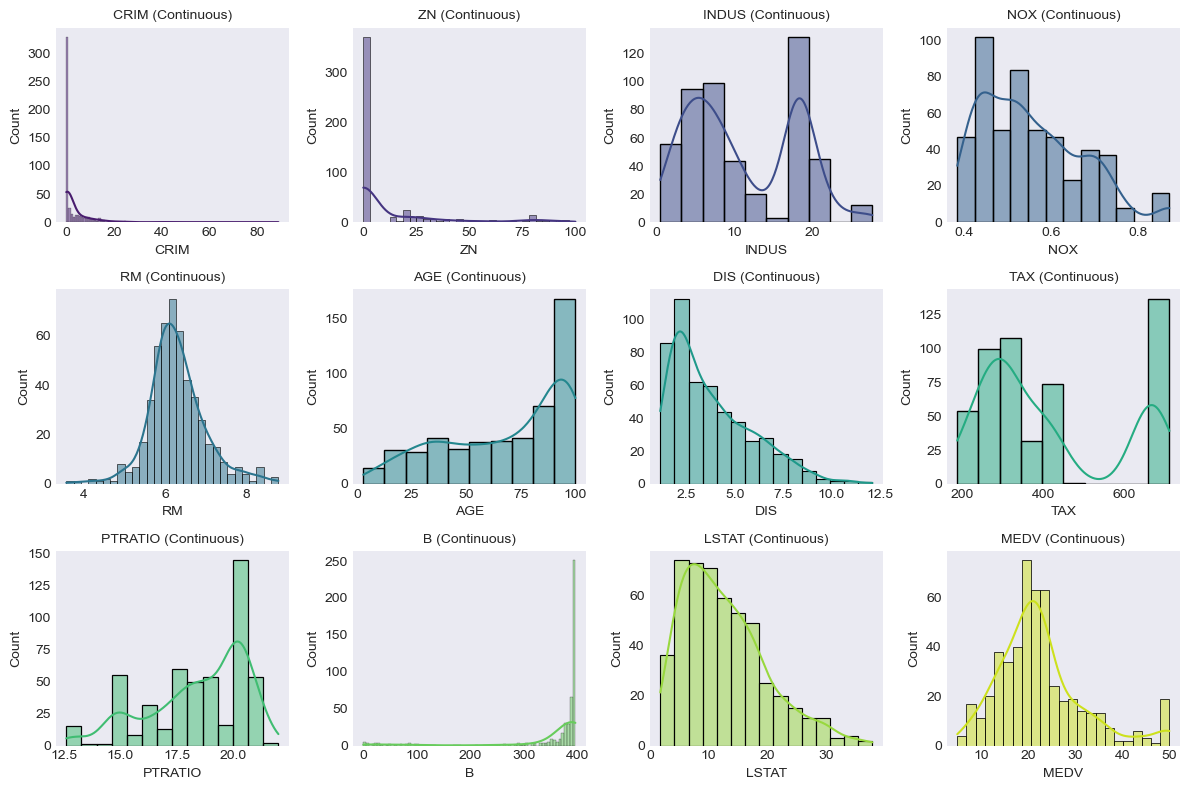

In [12]:
plotting_distribution(boston_dt, Height=8, Width=12, Color="white", Edge="black", Cols=4,mode ='Continuous')

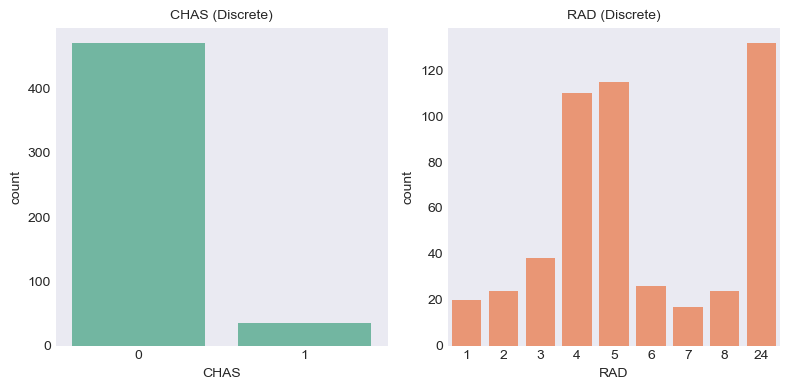

In [13]:
plotting_distribution(boston_dt, Height=4, Width=8, Color="white", Edge="black", Cols=2,mode='Discrete')

Bivariate analyses

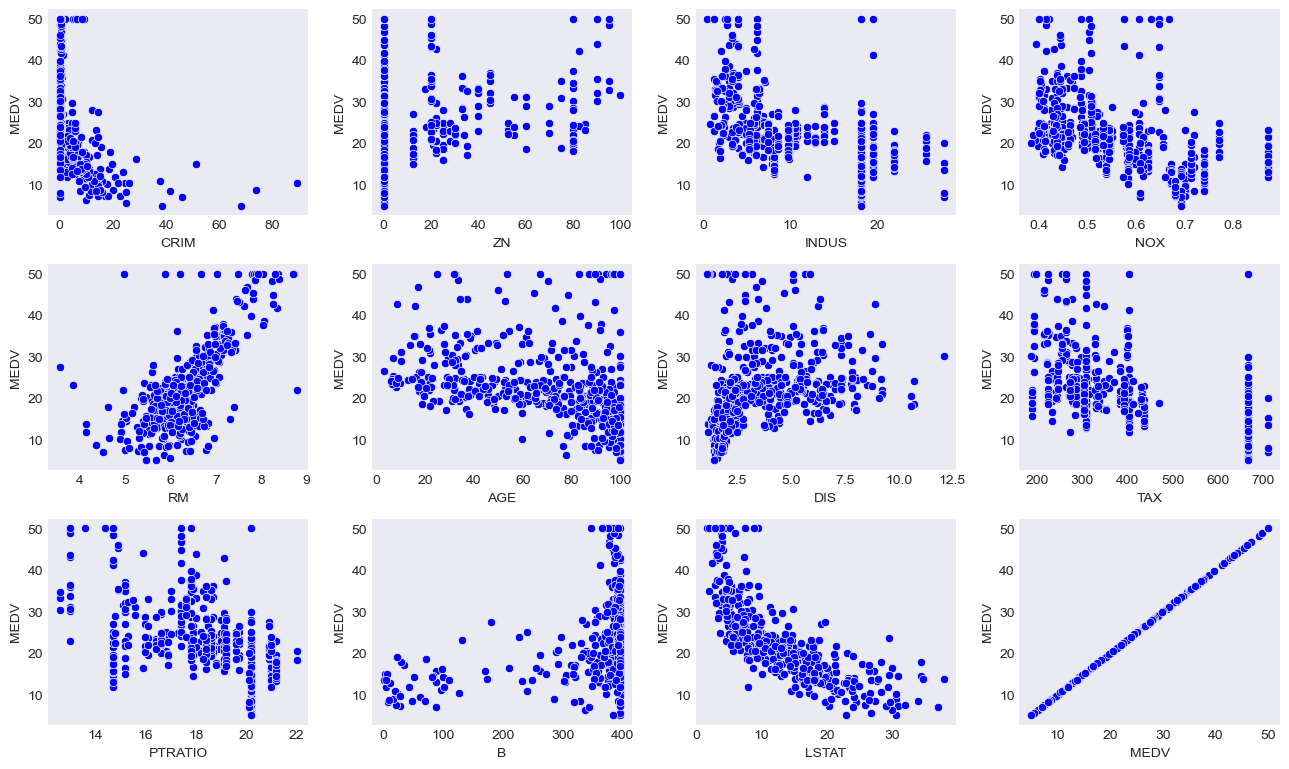

In [14]:
def Bimodel_visualization_Num():
    Nm = plt.figure(figsize=(13,10))
    for iN,it in enumerate(Continuous):
        Nm.add_subplot(int(np.ceil(len(Continuous) /3) ), 4, iN + 1)
        sns.scatterplot(x =it, y="MEDV", data=boston_dt,color='blue')
    plt.tight_layout()
    plt.show()
Bimodel_visualization_Num()

In [15]:
def bi_model_subplot(boston_dt, x: str, y: str, cols_per_row: int = 2):
    """
    bi-model visualization continous vs Discrete:
    - Box plot
    - Violin plot
    """
    sns.set_style("darkgrid")
    plots = ["BoxPlot", "ViolinPlot"]
    total = len(plots)
    rows = int(np.ceil(total / cols_per_row))
    plt.figure(figsize=(cols_per_row * 6, rows * 5))
    for i, p in enumerate(plots, 1):
        ax = plt.subplot(rows, cols_per_row, i)
        
        if p == "BoxPlot":
            sns.boxplot(data=boston_dt, x=x, y=y,ax=ax, color='cyan')
            ax.set_title("Scatterplot")

        elif p == "ViolinPlot":
            sns.violinplot(data=boston_dt, x=x, y=y, ax=ax, color='orange',facecolor='green')
            ax.set_title("2D KDE Density")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show() 

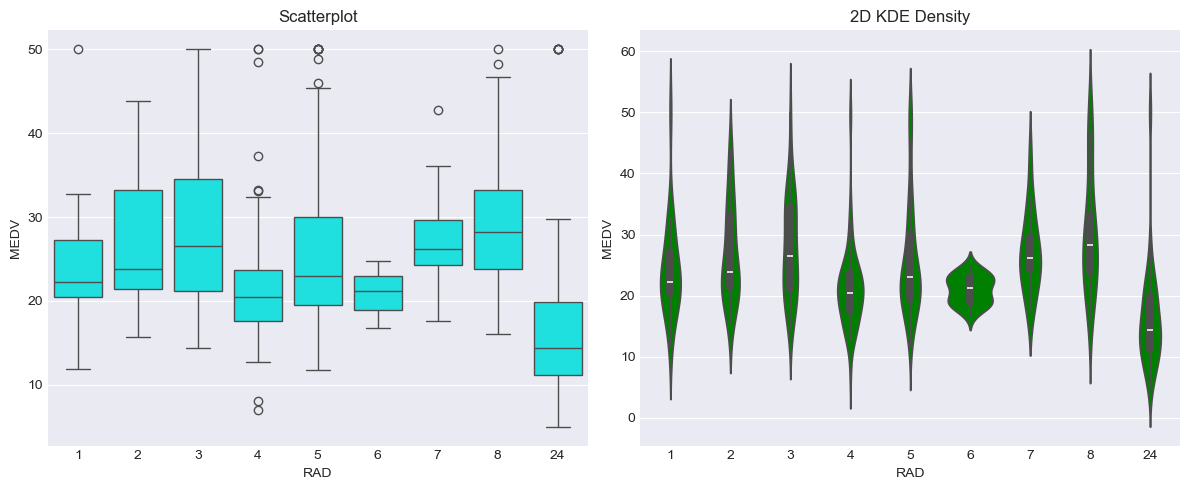

In [16]:
%matplotlib inline
bi_model_subplot(boston_dt,"RAD", "MEDV")

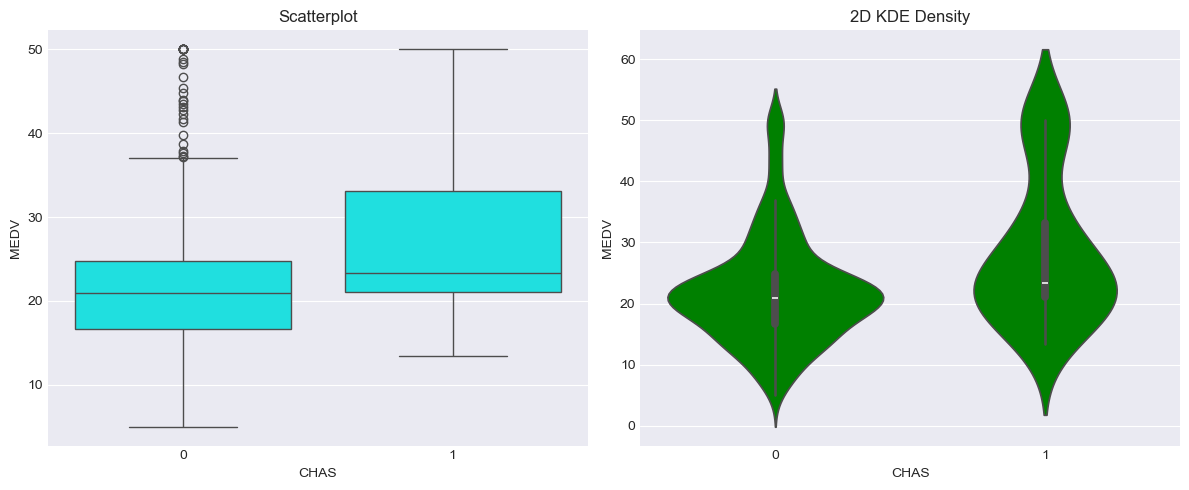

In [17]:
bi_model_subplot(boston_dt, "CHAS", "MEDV")

- Discrete columns:, ['CHAS', 'RAD']
- Continuous columns:, ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'] 

Multivariate Analyses

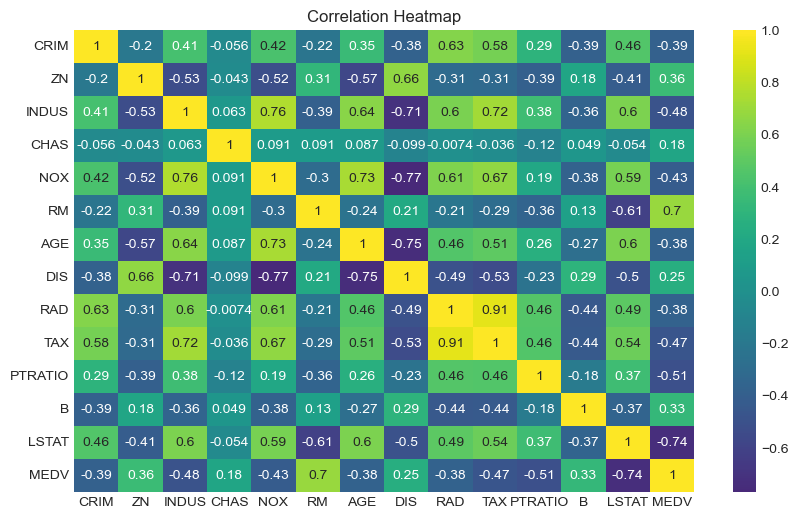

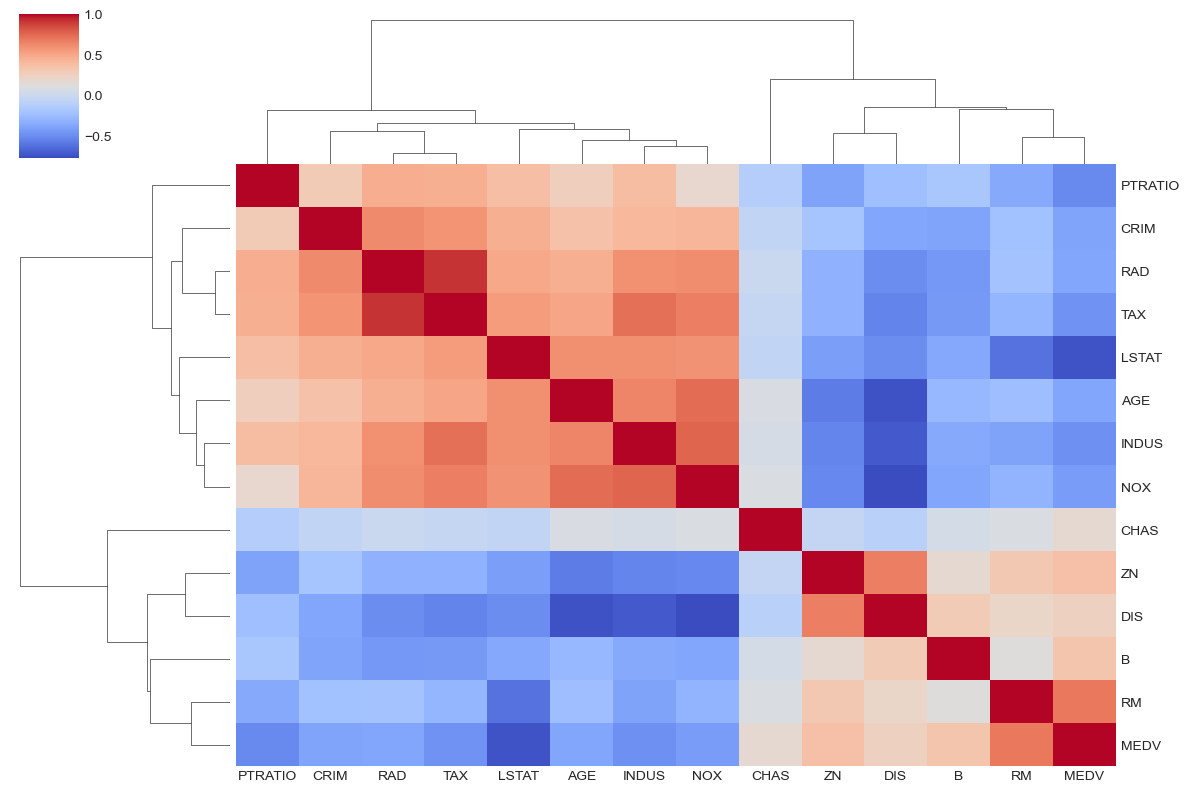


Top correlations with target:
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [18]:

def plot_correlation_structure(boston_dt: pd.DataFrame, target: str = "MEDV") -> None:
    """
    multivariate correlation visualization:
    - correlation heatmap
    - hierarchical clustered correlation map
    """
    corr = boston_dt.corr()

    # Standard correlation heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, cmap="viridis", center=0, annot=True)
    plt.title("Correlation Heatmap")
    plt.show()
    sns.clustermap(corr, cmap="coolwarm", figsize=(12, 8)) # Clustered heatmap
    plt.show()

    print("\nTop correlations with target:")
    print(corr[target].sort_values(ascending=False))
plot_correlation_structure(boston_dt, target= "MEDV")

RM,ZN,B,DIS,CHAS : are the most correlated with the MEDV , needed to be hadnle curefully if needed

In [19]:


def compute_vif(boston_dt: pd.DataFrame) -> pd.DataFrame: # Variance Inflation Factor (VIF) for numerical features
    numeric_boston_dt = boston_dt.select_dtypes(include=[np.number]).dropna()
    vif_boston_dt = pd.DataFrame()
    vif_boston_dt["feature"] = numeric_boston_dt.columns
    vif_boston_dt["VIF"] = [
        variance_inflation_factor(numeric_boston_dt.values, i)
        for i in range(numeric_boston_dt.shape[1])
    ]
    return vif_boston_dt

def display_vif(boston_dt: pd.DataFrame) -> None: #VIF table and flags high-multicollinearity features"
    vif_table = compute_vif(boston_dt)

    print("\n=== Variance Inflation Factor (VIF) ===")
    print(vif_table)

    high_vif = vif_table[vif_table["VIF"] > 5]

    if not high_vif.empty:
        print("\nHigh multicollinearity detected:")
        print(high_vif)
    else:
        print("\nNo serious multicollinearity.")
compute_vif(boston_dt)

,feature,VIF
0,CRIM,2.131404
1,ZN,2.910004
2,INDUS,14.485874
3,CHAS,1.176266
4,NOX,74.004269
5,RM,136.101743
6,AGE,21.398863
7,DIS,15.430455
8,RAD,15.369980
9,TAX,61.939713


- I have transformed data here to use pca and get a feel

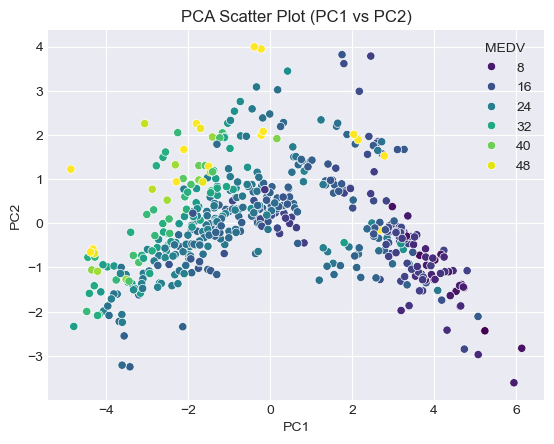


=== PCA Loadings ===
              PC1       PC2
CRIM     0.250951 -0.315252
ZN      -0.256315 -0.323313
INDUS    0.346672  0.112493
CHAS     0.005042  0.454829
NOX      0.342852  0.219116
RM      -0.189243  0.149332
AGE      0.313671  0.311978
DIS     -0.321544 -0.349070
RAD      0.319793 -0.271521
TAX      0.338469 -0.239454
PTRATIO  0.204942 -0.305897
B       -0.202973  0.238559
LSTAT    0.309760 -0.074322


In [20]:
def perform_pca(boston_dt: pd.DataFrame, target: str = "MEDV") -> None:
    """
      PCA analysis:
        - scale numerical features
        - compute PC1 & PC2
        - scatter plot colored by target
        - print PCA loadings
    """
    num_boston_dt = boston_dt.drop(columns=[target]).select_dtypes(include=[np.number])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(num_boston_dt)

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)

    pca_boston_dt = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        target: boston_dt[target]
    })

    sns.scatterplot(data=pca_boston_dt,x="PC1", y="PC2", hue=target,palette="viridis")
    plt.title("PCA Scatter Plot (PC1 vs PC2)")
    plt.show()

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=["PC1", "PC2"],
        index=num_boston_dt.columns
    )

    print("\n=== PCA Loadings ===")
    print(loadings)
perform_pca(boston_dt)